<a href="https://colab.research.google.com/github/ewst22ParkSY/ESAA11_PSY/blob/ESAA11_OB/ESAA_OB_WEEK6_1_transcript.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 10 텍스트 분석 실습 - 캐글 mercari Price Suggestion Challenge
- 일본의 대형 온라인 쇼핑몰인 Mercari(메루카리)사의 제품에 대해 가격을 예측하는 과제

데이터 세트 속성
- train_id: 데이터 id
- name: 제품명
- item_condition_id: 판매자가 제공하는 제품 상태
- category_name: 카테고리 명
- brand_name: 브랜드 이름
- price: 제품 가격, 예측을 위한 타깃 속성
- shipping: 배송비 무료 여부, 1이면 무료(판매자가 지불), 0이면 유료(구매자 지불)
- item_description: 제품에 대한 설명

price: 예측할 타깃 값

### 데이터 전처리

In [1]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas  as pd

mercari_df = pd.read_csv('/content/mercari_train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(23184, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


In [2]:
# 피처의 타입과 Null 여부 확인

print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23184 entries, 0 to 23183
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   train_id           23184 non-null  int64  
 1   name               23184 non-null  object 
 2   item_condition_id  23184 non-null  int64  
 3   category_name      23069 non-null  object 
 4   brand_name         13245 non-null  object 
 5   price              23184 non-null  float64
 6   shipping           23184 non-null  int64  
 7   item_description   23184 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 1.4+ MB
None


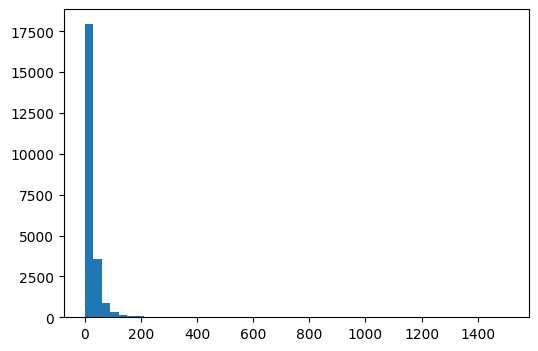

In [3]:
# price 칼럼의 데이터 분포도 살펴보기

import matplotlib.pyplot as plt
import seaborn as sns

y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
plt.hist(y_train_df, bins=50)
plt.show()

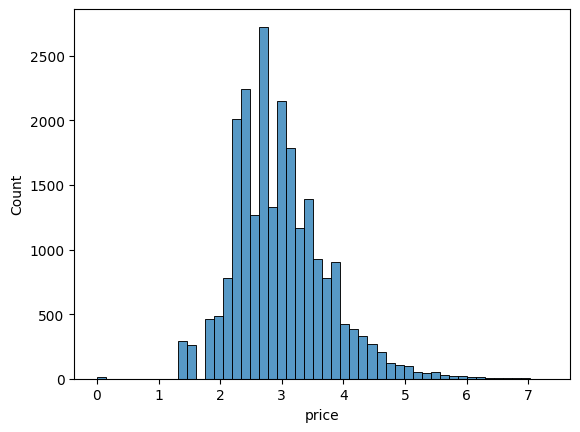

In [4]:
# 왜곡돼 분포돼있으니까 로그변환

import numpy as np

y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

In [5]:
# 데이터 세트에서도 로그변환 해주기

mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

,price
0,2.397895
1,3.970292
2,2.397895


In [6]:
# 다른 피처의 값도 살피기 (shipping, item_condition_id)

print('Shipping 값 유형: \n', mercari_df['shipping'].value_counts())
print("")
print('item_condition_id 값 유형: \n', mercari_df['item_condition_id'].value_counts())

Shipping 값 유형: 
 shipping
0    12797
1    10387
Name: count, dtype: int64

item_condition_id 값 유형: 
 item_condition_id
1    10062
3     6756
2     5814
4      513
5       39
Name: count, dtype: int64


In [7]:
# item_description 칼럼은 Null 값은 별로 없지만 description에 대한 별도 설명이 없는 경우 'No description yet' 값으로 되어있음.
# 그러니 이 값이 얼마나 있는지 확인

boolean_cond = mercari_df['item_description']=='No description yet'
mercari_df[boolean_cond]['item_description'].count()

np.int64(1302)

category_name 살펴보기
- '/'로 분리된 카테고리를 하나의 문자열로 나타내고 있음
- 피처 추출 시 tokenizer를 '/'로 하여 단어를 분리해 벡터화할 수 있지만, category_name의 '/'를 기준으로 단어를 토큰화해 각각 별도의 피처로 저장하고 이를 이용해 알고리즘을 학습

In [8]:
# apply lambda에서 호출되는 대, 중, 소 분할 함수 생성, 대, 중, 소 값을 리스트로 변환
def split_cat(category_name):
      try:
            return category_name.split('/')
      except:
            return ['Other_Null', 'Other_Null', 'Other_Null']

# 위의 split_cat()을 apply lambda에서 호출해 대, 중, 소 칼럼을 mercari_df에 생성.
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))

# 대분류만 값의 유형과 건수를 살펴보고, 중분류, 소분류는 값의 유형이 많으므로 분류 개수만 추출
print('대분류 유형 :\n', mercari_df['cat_dae'].value_counts())
print('중분류 개수 :', mercari_df['cat_jung'].nunique())
print('소분류 개수:', mercari_df['cat_so'].nunique())

대분류 유형 :
 cat_dae
Women                     10363
Beauty                     3404
Kids                       2636
Electronics                1929
Men                        1437
Home                       1001
Other                       744
Vintage & Collectibles      735
Handmade                    445
Sports & Outdoors           375
Other_Null                  115
Name: count, dtype: int64
중분류 개수 : 109
소분류 개수: 573


In [9]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

# 각 칼럼별로 Null 값 건수 확인. 모두 0이 나와야 합니다.
mercari_df.isnull().sum()

,0
train_id,0
name,0
item_condition_id,0
category_name,0
brand_name,0
price,0
shipping,0
item_description,0
cat_dae,0
cat_jung,0


## 피처 인코딩과 피처 벡터화



In [10]:
# 상품 브랜드명이 어떤 유형으로 돼 있는지 유형 건수와 대표적인 브랜드명을 5개 정도만 살펴보기

print('brand name의 유형 건수 : ', mercari_df['brand_name'].unique())
print('brand name sample 5건 : \n', mercari_df['brand_name'].value_counts()[:5])

brand name의 유형 건수 :  ['Other_Null' 'Razer' 'Target' ... 'DYMO' 'Wilson' 'BUNN']
brand name sample 5건 : 
 brand_name
Other_Null           9939
PINK                  872
Nike                  826
Victoria's Secret     725
LuLaRoe               466
Name: count, dtype: int64


In [11]:
print('name 의 종류 개수 : ', mercari_df['name'].unique())
print('name sample 5건 : \n', mercari_df['name'][:7])

name 의 종류 개수 :  ['MLB Cincinnati Reds T Shirt Size XL' 'Razer BlackWidow Chroma Keyboard'
 'AVA-VIV Blouse' ... "New Victoria's Secret Sports Bra 36B"
 'NEW VS Pink S Thong Panty Underwear Sexy'
 'Spanx super power panties size B nude']
name sample 5건 : 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


- Name 속성 : 유형이 매우 많고 적은 단어 위주의 텍스트 형태이므로 Count 기반으로 피처 벡터화 변환
- Category_name 칼럼: dae, jung, so 원-핫 인코딩 적용
- shipping, item_condition_id: 원-핫 인코딩
- item_description: 가장 긴 텍스트를 가지고 있으며 평균 문자열 크기와 2개 정도의 텍스트만 추출

In [12]:
pd.set_option('max_colwidth', 200)

# item_descriotion의 평균 문자열 크기
print('item_description 평균 문자열 크기 : ', mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 문자열 크기 :  145.88988095238096


,item_description
0,No description yet
1,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.


평균 문자열이 145자로 비교적 크므로 해당 칼럼은 TF-IDF 변환

In [13]:
# 주요 칼럼 인코딩 및 피처 벡터화 변환

# name 속성에 대한 피처 벡터화 변환
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df.name)

# item_descriotion에 대한 피처 벡터화 변환
tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1,3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vectorization shape : ' , X_name.shape)
print('description vectorization shape : ', X_descp.shape)

name vectorization shape :  (23184, 12127)
description vectorization shape :  (23184, 50000)


CountVectorizer, TfidfVectorizer가 fit_transform()을 통해 반환하는 데이터는 희소 행렬 형태
- 희소 행렬 객체 변수인 X_name과 X_descp를 새로 결합해 새로운 데이터 세트를 구성해야 하고, 앞으로 인코딩될 cat_dae, cat_jung, cat_so, brand_name, shipping, item_condition_idf도 모두 X_name, X_descp와 결합돼 ML 모델을 실행하는 기반 데이터 세트로 재구성돼야 함.
- 인코딩 대상 칼럼을 밀집 형태가 아닌 희소 행렬 형태로 인코딩을 적용한 뒤, 함께 결합

#### 원-핫 인코딩
OneHotEncoder / LabelBinarizer
-LabelBinarizer: 희소 행렬 형태의 원-핫 인코딩 변호나을 지원. (sparse_out=True로 파라미터 설정하면 됨.)<br>
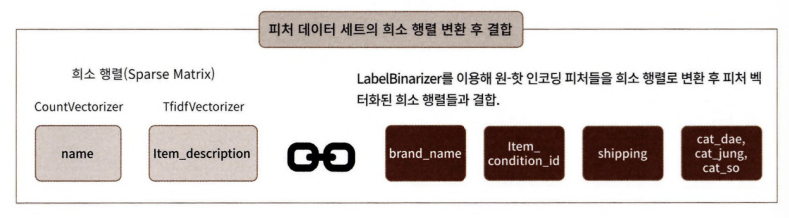


In [14]:
from sklearn.preprocessing import LabelBinarizer

# brand_name, item_condition_id, shipping 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])
lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])
lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

# cat_dae, cat_jung, cat_so 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])
lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])
lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

In [15]:
# 생성된 인코딩 데이터 세트의 타입과 shape 살피기
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape:{0}, X_item_cond_id_shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape:(23184, 1103), X_item_cond_id_shape:(23184, 5)
X_shipping shape:(23184, 1), X_cat_dae shape:(23184, 11)
X_cat_jung shape:(23184, 109), X_cat_so shape:(23184, 573)


In [16]:
# hstack()을 이용해 피처벡터화 변환된 데이터 세트와 희소 인코딩 변환된 데이터 세트를 결합

from scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, \
                                         X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# hstack 함수를 이용해 인코딩과 벡터화를 수행한 데이터 세트를 모두 결합.
X_features_sparse = hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

# 데이터 세트가 메모리를 많이 차지하므로 사용 목적이 끝났으면 바로 메모리에서 삭제
del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (23184, 63929)


5696

hstack()으로 결합한 데이터 세트는 csr_matrix 타입

### 릿지 회귀 모델 구축 및 평가
적용할 평가 지표: RMSLE
> 낮은 가격(price)보다 높은 가격에서 오류가 발생할 경우 오류 값이 더 커지는 것을 억제하기 위해서 이 방식 도입

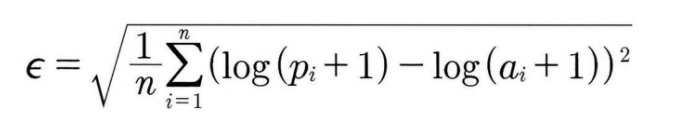

주의할 점
- 원본 데이터의 price 칼럼의 값은 왜곡된 데이터 분포를 갖고 있기 때문에 이를 정규 분포 형태로 유도하기 위해 로그 값을 취해 변환했음.
> 학습할 모델이 사용할 price 값은 로그 값으로 변환된 price 값이므로 예측도 당연히!! 로그로 변환한 데이터 값 수준의 price값을 예측할 것.
- 따라서 학습 모델을 이용한 예측된 price 값은 다시 로그의 역변환인 지수변환을 수행해 원복해야함!

In [17]:
def rmsle(y, y_pred):
      # underflow, overflow를 막기 위해 log가 아닌 log1p로 rmsle 계산
      return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):

      # 원본 데이터는 log1p로 변환되었으므로 exmpm1로 원복 필요.
      preds_exmpm = np.expm1(preds)
      y_test_exmpm = np.expm1(y_test)

      # rmsle로 RMSLE값 추출
      rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
      return rmsle_result

In [18]:
# 학습용 데이터를 생성하고, 모델을 학습/예측하는 로직의 함수
# model_train_predict() 함수는 model인자로 사이킷런의 estimator 객체를, matrix_list 인자로 최종 데이터 세트로 결합한 희소 행렬 리스트를 가짐.

import gc
from scipy.sparse import hstack

def model_train_predict(model, matrix_list):
        # scipy.sparse 모듈의 hstack을 이용해 희소 행렬 결합
        X=hstack(matrix_list).tocsr()

        X_train, X_test, y_train, y_test = train_test_split(X, mercari_df['price'],
                                                                                                    test_size=0.2, random_state=156)
        # 모델 학습 및 예측
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        del X, X_train, X_test, y_train
        gc.collect()

        return preds, y_test

In [19]:
# 텍스트 형태의 속성이 상품 가격 예측에 얼마나 영향을 미치는지 알아보기

linear_model = Ridge(solver = "lsqr", fit_intercept=False)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id, \
                                         X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값:', evaluate_org_price(y_test, linear_preds))

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id, \
                                         X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 포함했을 때 rmsle 값:', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle 값: 0.5690951611902513
Item Description을 포함했을 때 rmsle 값: 0.549747603718361


### LightGBM 회귀 모델 구축과 앙상블을 이용한 최종 예측 평가

In [20]:
# LGBM 회귀 수행

from lightgbm import LGBMRegressor

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
                                         X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
lgbm_model = LGBMRegressor(n_estimators=100, learning_rate = 0.5, num_leaves=125, random_state=156)
lgbm_preds, y_test = model_train_predict(model=lgbm_model, matrix_list=sparse_matrix_list)
print('LightGBM rmsle 값: ', evaluate_org_price(y_test, lgbm_preds))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.220162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 82182
[LightGBM] [Info] Number of data points in the train set: 18547, number of used features: 3896
[LightGBM] [Info] Start training from score 2.978241


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LightGBM rmsle 값:  0.6159380900389253


In [21]:
# 간단 앙상블

preds = lgbm_preds * 0.45 + linear_preds * 0.55
print('LightGBM과 Ridge를 ensemble한 최종 rmsle 값 : ', evaluate_org_price(y_test, preds))

LightGBM과 Ridge를 ensemble한 최종 rmsle 값 :  0.5419050368508662
